In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import torch
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

from seisfwi.model import AcousticModel, RockPhysicsGassmann
from seisfwi.propagator import AcousticPropagator

from utils import RockPhysicsModel
from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings

from HMC_FWI_VAE import get_survey

In [17]:
configure_plot_settings()

### Distribution of Meta parameters

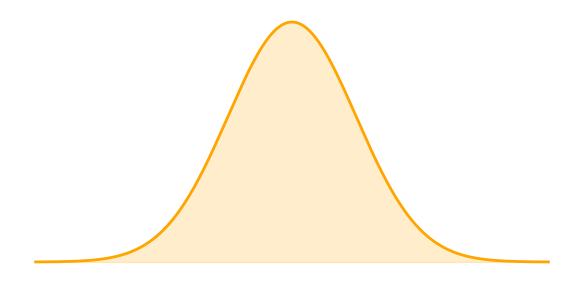

In [18]:
# plot a gaussian distribution
plt.figure(figsize=(6, 3))
x = np.linspace(-4, 4, 1000)
mean = 0
std = 1
pdf = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x, pdf, color="orange", linewidth=2)
plt.fill_between(x, pdf, color='orange', alpha=0.2)

# Remove all spines (box)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.savefig("figures/workflow/dist.png", dpi=300, transparent=True)
plt.show()

### Reservoir Realizations

In [19]:
id = [1000, 3000, 3500, 800]
path_2D = Path('/net/vision/scr2/haipeng/FWI-HMC/model2D')
po_co2 = np.load(path_2D / f'po_prior_slice64_8002_samples_5m.npy')[id]
sa_co2 = np.load(path_2D / f'sa_prior_time25_slice64_8002_samples_5m.npy')[id]

nz0 = 260
nx0 = 110
nz_res = po_co2[0].shape[0]
nx_res = po_co2[0].shape[1]
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 

extent = [x_res[0], x_res[-1], z_res[-1], z_res[0]]
print(nx_res, nz_res)

179 15


In [20]:
for i in range(len(id)):
    plt.figure(figsize=(6, 2.5))
    plt.imshow(po_co2[i], cmap="turbo", extent=extent, aspect='auto', vmin=0, vmax=0.4)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f"figures/workflow/poso{i}.png", dpi=300, transparent=True)
    plt.close()    
    
    plt.figure(figsize=(6, 2.5))
    plt.imshow(sa_co2[i], cmap="inferno", extent=extent, aspect='auto', vmin=0, vmax=0.5)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f"figures/workflow/sat{i}.png", dpi=300, transparent=True)
    plt.close()

### VAE Compression

In [21]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC/')

# Model
in_channels = 1
latent_dim = 64
kld_weight = 0.000015
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload the model
checkpoint_path = path / f"VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"
vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load(checkpoint_path, map_location=device))
vae.eval()
None

In [22]:
sa_co2_ori = torch.tensor(sa_co2[-1]).unsqueeze(0).unsqueeze(0).float().to(device)
sa_co2_interp = torch.nn.functional.interpolate(sa_co2_ori, size=(64, 64), mode='bilinear', align_corners=False)

sa_co2_vae = vae.generate(sa_co2_interp)
sa_co2_vae = torch.nn.functional.interpolate(sa_co2_vae, size=(15, 179), mode='bilinear', align_corners=False)

sa_co2_ori = sa_co2_ori.squeeze().cpu().numpy()
sa_co2_vae = sa_co2_vae.squeeze().cpu().detach().numpy()

In [23]:

plt.figure(figsize=(6, 2.5))
plt.imshow(sa_co2_ori, cmap="inferno", extent=extent, aspect='auto', vmin=0, vmax=0.5)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#1f77b4')   # apply new color

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(f"figures/workflow/sat_ori.png", dpi=300, transparent=True)
plt.close()

plt.figure(figsize=(6, 2.5))
plt.imshow(sa_co2_vae, cmap="inferno", extent=extent, aspect='auto', vmin=0, vmax=0.5)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(f"figures/workflow/sat_vae.png", dpi=300, transparent=True)
plt.close()

### Rock Physics

In [24]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [25]:
vp_co2_ori, _, _ = rockphy(sa_co2_ori)
vp_co2_vae, _, _ = rockphy(sa_co2_vae)

vp_co2_ori = vp_co2_ori.cpu().detach().numpy()
vp_co2_vae = vp_co2_vae.cpu().detach().numpy()

In [26]:
plt.figure(figsize=(6, 2.5))
plt.imshow(vp_co2_ori, cmap="jet", extent=extent, aspect='auto', vmin=-240, vmax=240)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('k')   # apply new color

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(f"figures/workflow/vp_ori.png", dpi=300, transparent=True)
plt.close()


plt.figure(figsize=(6, 2.5))
plt.imshow(vp_co2_vae, cmap="jet", extent=extent, aspect='auto', vmin=-240, vmax=240)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('k')   # apply new color

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(f"figures/workflow/vp_vae.png", dpi=300, transparent=True)
plt.close()

### Waveform Modeling

In [27]:
# Get model, survey and data parameters
f0 = 30
src_id = 4
_, _, survey = get_survey(f0=f0, src_id=src_id)

ox, oz = 0.0, 0.0
nx, nz = 401, 346
dx, dz = 5.0, 5.0
free_surface =True

vp_bl = np.load('model/vp_bl_nz346_nx401_5m.npy')
vp_ml_ori = vp_bl.copy()
vp_ml_vae = vp_bl.copy()
vp_ml_ori[nz0:nz0+nz_res, nx0:nx0+nx_res] += vp_co2_ori
vp_ml_vae[nz0:nz0+nz_res, nx0:nx0+nx_res] += vp_co2_vae

model_bl     = AcousticModel(ox, oz, dx, dz, nx, nz, vp = vp_bl, free_surface=free_surface)
model_ml_ori = AcousticModel(ox, oz, dx, dz, nx, nz, vp = vp_ml_ori, free_surface=free_surface)
model_ml_vae = AcousticModel(ox, oz, dx, dz, nx, nz, vp = vp_ml_vae, free_surface=free_surface)


In [28]:
F = AcousticPropagator(model_bl, survey)
dobs_bl     = F(model_bl)
dobs_ml_ori = F(model_ml_ori)
dobs_ml_vae = F(model_ml_vae)

2025-11-24 22:42:45,858 - INFO - Survey analysis completed: all sources and receivers within model range.


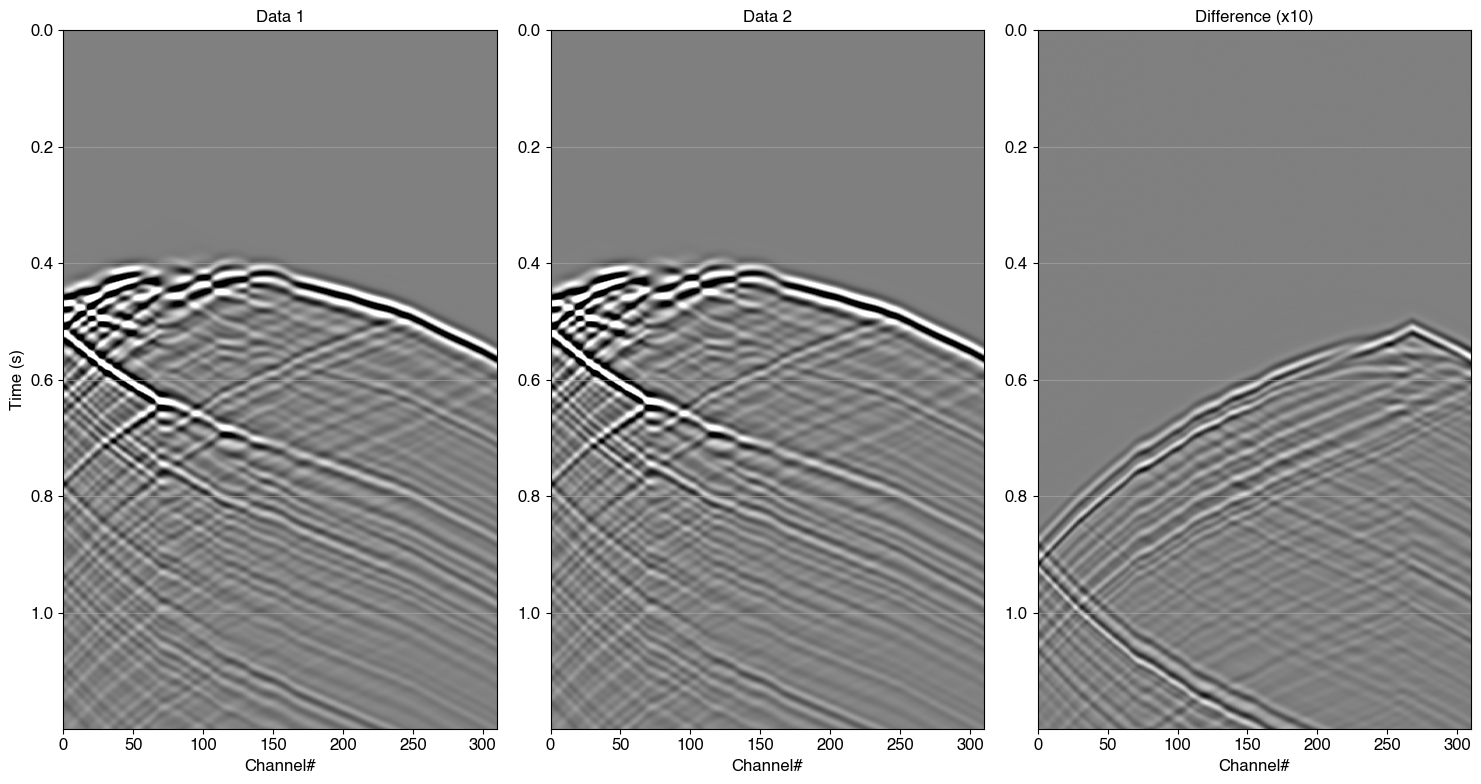

In [29]:
dobs_ml_ori.plot_compare(dobs_bl, comp=['pr'], ratio=10, pclip=99)

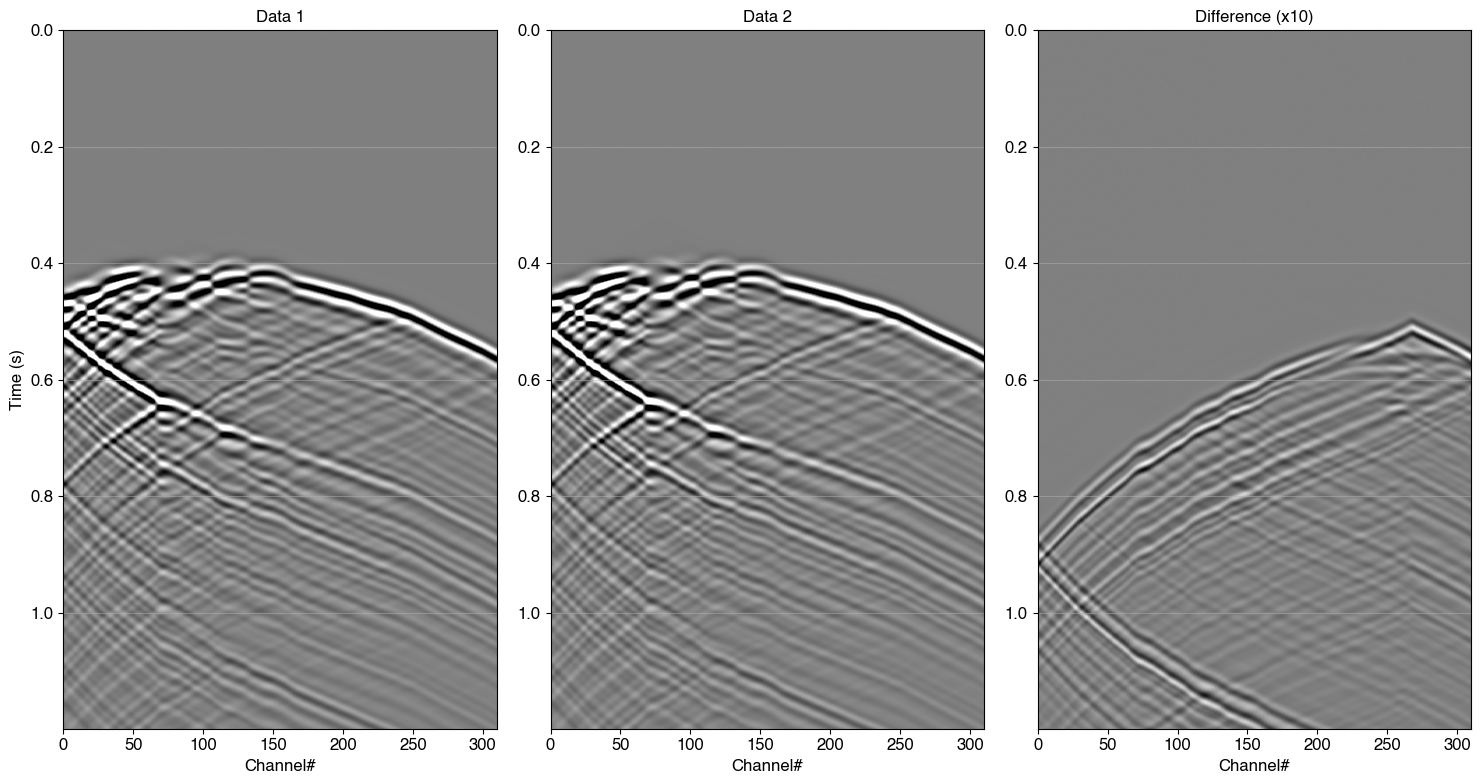

In [30]:
dobs_ml_vae.plot_compare(dobs_bl, comp=['pr'], ratio=10, pclip=99)

In [31]:
idx = 280

trace_bl     = dobs_bl.data['pr'].cpu().numpy().squeeze()[idx]/100
trace_ml_ori = dobs_ml_ori.data['pr'].cpu().numpy().squeeze()[idx]/100
trace_ml_vae = dobs_ml_vae.data['pr'].cpu().numpy().squeeze()[idx]/100
t = dobs_bl.t

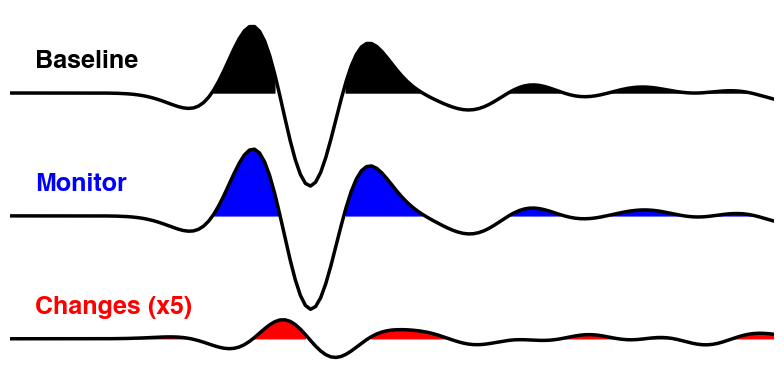

In [32]:
c_bl   = "k"   # Deep Blue
c_ml   = "blue"   # Deep Red
c_diff = "red"   # Dark Orange

off_bl   = 0.0
off_ml   = -1.25
off_diff = off_ml *2 

plt.figure(figsize=(8, 4))
y_bl = trace_bl + off_bl
plt.plot(t, y_bl, color='k', linewidth=2.5)
plt.fill_between(t, y_bl, off_bl, where=(y_bl > off_bl), color=c_bl, alpha=1)
plt.text(0.475, 0.25, "Baseline", color=c_bl, fontsize=18, fontweight='bold')

y_ml = trace_ml_ori + off_ml
plt.plot(t, y_ml, color='k', linewidth=2.5)
plt.fill_between(t, y_ml, off_ml, where=(y_ml > off_ml), color=c_ml, alpha=1)
plt.text(0.475, 0.25+off_ml, "Monitor", color=c_ml, fontsize=18, fontweight='bold')

trace_diff = (trace_ml_ori - trace_bl)*5 + off_diff
plt.plot(t, trace_diff, color='k', linewidth=2.5)
plt.fill_between(t, trace_diff, off_diff, where=(trace_diff > off_diff), color=c_diff, alpha=1)
plt.text(0.475, 0.25+off_diff, "Changes (x5)", color=c_diff, fontsize=18, fontweight='bold')

plt.xlim(0.47, 0.62)
plt.grid(linestyle="--", linewidth=0.6, alpha=0.5)

# Thicker axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_visible(False)

plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.savefig(f"figures/workflow/waveform.png", dpi=300, transparent=True)
plt.show()


### Plot posterior distributions